# Advanced Topics

This notebook covers lower-level features for users who need fine-grained control
over the NSQ simulation:

1. **Coordinate system tilts and decenters** — rotating and shifting components
2. **Raw component construction** — building surfaces directly from geometry primitives
3. **RayDatabase analysis** — post-processing phase-space data
4. **Scene validation and diagnostics**
5. **Tips for large simulations** — batch size, memory, and performance
6. **Rare-path sampling** — biasing ray budget toward faint ghosts without changing the answer

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig, PointSourceConfig,
    IrradianceDetectorConfig, RayDatabaseConfig,
    LensConfig,
    RefractiveComponent,
    NSQMaterial, VACUUM,
)
from optiland.nonsequential.components.geometry.analytic.sphere import SphereGeometry
from optiland.nonsequential.ir.scene_ir import SamplingPolicy

spec = Spectrum.monochromatic(0.55)

# The demo singlet: biconvex N-BK7, f = 49.1 mm, back focal distance 47.4 mm
# from the rear vertex. Front vertex at z = 0 plus 5 mm centre thickness puts
# the focus at z = 52.4 mm, which is where detectors go unless a cell is
# deliberately looking at the beam away from focus.
DEMO_LENS = LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                       front_aperture_radius=12.5)
FOCUS_Z = 52.4


## 1. Coordinate System Tilts and Decenters

Every component, source, and detector has a `CoordinateSystem` that defines its
position (`x`, `y`, `z` in mm) and orientation (`rx`, `ry`, `rz` in radians).

| Parameter | Effect |
|---|---|
| `x`, `y`, `z` | Translate the element origin |
| `rx` | Rotate around the x-axis (tilt in YZ plane) |
| `ry` | Rotate around the y-axis (tilt in XZ plane) |
| `rz` | Rotate around the z-axis (twist) |

Rotations apply in the order rx → ry → rz (extrinsic Euler angles).

Tilting a rotationally symmetric lens breaks that symmetry, and the spot picks
up the aberrations of an off-axis field: the centroid walks off axis, and the
spot grows a one-sided comatic flare along the tilt axis.

Two things make or break this measurement. The detector has to be **at focus** —
at z = 100 mm this lens produces a 7.5 mm defocus blur, and a few tenths of a
millimetre of coma on top of that is invisible. And the maps need a **shared
colour scale**, or matplotlib renormalises each panel and hides the very
difference you are looking for.


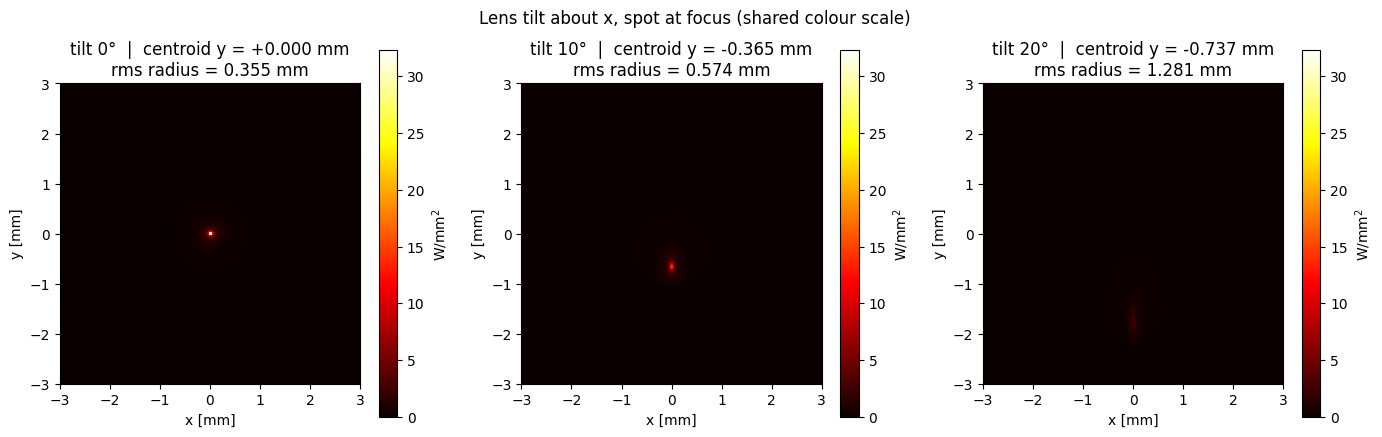

tilt  0.0°: centroid y = +0.000 mm, rms radius = 0.355 mm
tilt 10.0°: centroid y = -0.365 mm, rms radius = 0.574 mm
tilt 20.0°: centroid y = -0.737 mm, rms radius = 1.281 mm


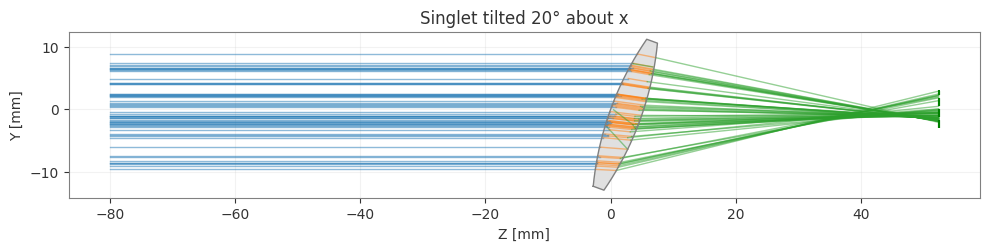

In [2]:
def lens_spot(rx_deg=0.0, n_rays=200_000, half_width=3.0):
    """Trace the demo singlet tilted by rx_deg; detector at focus.

    Returns the RayDatabase. Note the single detector: detectors absorb, so a
    RayDatabase stacked in front of an IrradianceDetector would swallow every
    ray and leave the irradiance map empty. Everything below is derived from
    the one phase-space record instead.
    """
    scene = NSQScene()
    scene.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=10.0),
    )
    scene.add_lens('L', CoordinateSystem(z=0, rx=np.radians(rx_deg)), DEMO_LENS)
    scene.add_detector(
        'RDB', CoordinateSystem(z=FOCUS_Z),
        RayDatabaseConfig(width=2 * half_width, height=2 * half_width),
    )
    return scene.trace(num_rays=n_rays, seed=42).detectors['RDB']


def spot_stats(db):
    """Flux-weighted centroid and rms radius of a RayDatabase spot."""
    cx = np.average(db.x, weights=db.flux)
    cy = np.average(db.y, weights=db.flux)
    rms = np.sqrt(np.average((db.x - cx)**2 + (db.y - cy)**2, weights=db.flux))
    return cx, cy, rms


tilts = [0.0, 10.0, 20.0]
dbs = [lens_spot(rx) for rx in tilts]

# Bin each database onto a common grid so the panels are directly comparable.
HALF = 3.0
edges = np.linspace(-HALF, HALF, 193)
pixel_area = (edges[1] - edges[0]) ** 2
maps = [np.histogram2d(db.y, db.x, bins=[edges, edges],
                       weights=db.flux)[0] / pixel_area for db in dbs]
vmax = max(m.max() for m in maps)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, rx, db, E in zip(axes, tilts, dbs, maps):
    cx, cy, rms = spot_stats(db)
    im = ax.imshow(E, origin='lower', cmap='hot', aspect='equal',
                   extent=[-HALF, HALF, -HALF, HALF], vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(f'tilt {rx:g}\u00b0  |  centroid y = {cy:+.3f} mm\n'
                 f'rms radius = {rms:.3f} mm')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Lens tilt about x, spot at focus (shared colour scale)', fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

for rx, db in zip(tilts, dbs):
    cx, cy, rms = spot_stats(db)
    print(f"tilt {rx:4.1f}\u00b0: centroid y = {cy:+.3f} mm, rms radius = {rms:.3f} mm")

# The same scene, seen from the side.
scene_tilt = NSQScene()
scene_tilt.add_source('S', CoordinateSystem(z=-80),
                      CollimatedSourceConfig(spec, total_flux=1.0,
                                             aperture_radius=10.0))
scene_tilt.add_lens('L', CoordinateSystem(z=0, rx=np.radians(20)), DEMO_LENS)
scene_tilt.add_detector('D', CoordinateSystem(z=FOCUS_Z),
                        IrradianceDetectorConfig(width=6, height=6))
scene_tilt.view(num_rays=60, color_by='bounce',
                title='Singlet tilted 20\u00b0 about x')
plt.show()


## 2. Raw Component Construction

For geometries not covered by `Lens`, `Mirror`, or `Doublet`, you can construct
raw `BaseComponent` objects directly from geometry primitives and register them
via `scene.add_component()`.

Available geometry classes:

| Geometry | Shape, in its own coordinate system |
|---|---|
| `FinitePlaneGeometry(width, height)` | rectangular flat surface at z = 0 |
| `AnnularPlaneGeometry(inner_radius, outer_radius)` | annular flat surface at z = 0 |
| `SphereGeometry(radius, aperture_radius)` | **complete sphere centred on the origin** |
| `ConicGeometry(radius, conic, aperture_radius)` | conic surface, vertex at z = 0 |
| `CylindricalFrustumGeometry(r_front, r_back, z_front, z_back)` | barrel surface |

`SphereGeometry` is the one that catches people out. It is a whole sphere
centred at the origin of its coordinate system — not a vertex-at-origin cap like
`ConicGeometry` — so its poles sit at z = ±`radius`, and the sign of `radius` is
irrelevant. That makes it the natural primitive for a **solid**: one component,
crossed twice.

A `RefractiveComponent` works out which medium a ray is leaving from the index
the ray is already travelling in, not from the surface normal, so the same
component refracts correctly on the way in and on the way out. A ball lens is
therefore a single `SphereGeometry`, not two.


n(0.55 µm) = 1.5185
Ball lens EFL from centre = 7.321 mm  ->  paraxial focus at z = 7.321


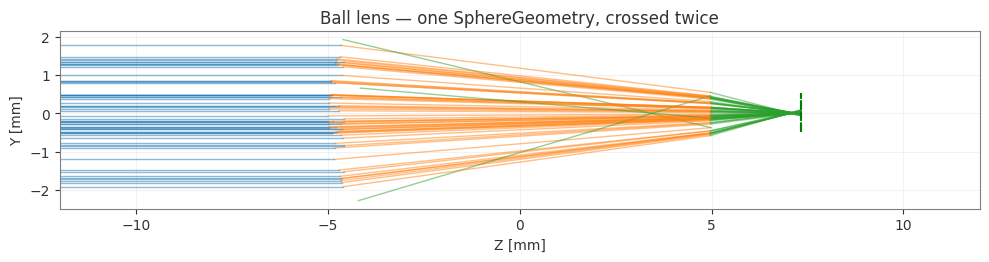

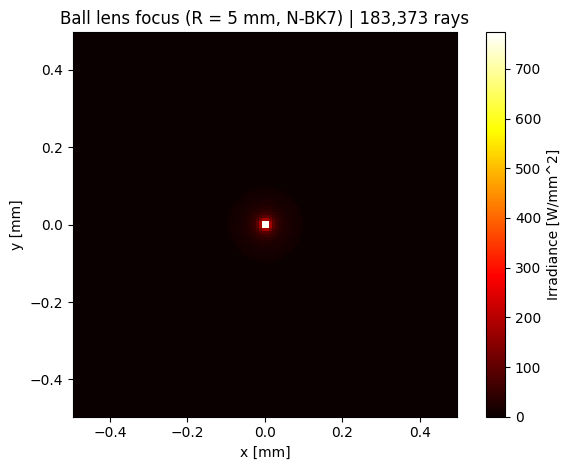


Detected flux: 0.9154 W of 1.0 W
Flux conservation error: 1.25e-16


In [3]:
# A ball lens: one sphere, entered and exited by the same component.
glass = NSQMaterial.from_glass('N-BK7')
BALL_R = 5.0

ball = RefractiveComponent(
    cs=CoordinateSystem(z=0),                      # sphere centred at z = 0
    geometry=SphereGeometry(radius=BALL_R, aperture_radius=4.0),
    material_front=VACUUM,                         # outside the ball
    material_back=glass,                           # inside the ball
    name='ball',
)

# A ball lens of radius R and index n has EFL = nR / (2(n-1)) measured from its
# centre, so the paraxial focus follows straight from the prescription.
n_bk7 = float(np.asarray(glass.n(np.array([0.55]))).ravel()[0])
f_ball = n_bk7 * BALL_R / (2 * (n_bk7 - 1))
print(f"n(0.55 \u00b5m) = {n_bk7:.4f}")
print(f"Ball lens EFL from centre = {f_ball:.3f} mm  ->  paraxial focus at z = {f_ball:.3f}")

scene_ball = NSQScene()
scene_ball.add_source(
    'S', CoordinateSystem(z=-30),
    CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=2.0),
)
scene_ball.add_component('ball', ball)
scene_ball.add_detector(
    'D', CoordinateSystem(z=f_ball),
    IrradianceDetectorConfig(width=1.0, height=1.0, num_pixels_x=128, num_pixels_y=128),
)

result_ball = scene_ball.trace(num_rays=200_000, seed=42)
irr_ball = result_ball.detectors['D']

# The 2D viewer draws compound components (Lens, Mirror, Doublet) and
# detectors; a raw component registered with add_component() has no renderer,
# so the sphere itself is not outlined here. The ray colours still tell the
# story: blue into the ball, orange inside the glass, green on the way out.
scene_ball.view(num_rays=60, color_by='bounce',
                title='Ball lens \u2014 one SphereGeometry, crossed twice',
                xlim=(-12, 12))
plt.show()

fig = irr_ball.plot(cmap='hot')
plt.title(f'Ball lens focus (R = {BALL_R:g} mm, N-BK7) | {irr_ball.num_rays_hit:,} rays')
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"\nDetected flux: {irr_ball.total_flux:.4f} W of {result_ball.total_flux_in:.1f} W")
print(f"Flux conservation error: {result_ball.flux_conservation_error:.2e}")


## 3. RayDatabase: Phase-Space Analysis

The `RayDatabase` from a `RayDatabaseDetector` gives access to the complete
phase-space of every ray that hit the detector. This supports analyses that the
binned detectors cannot provide, such as:
- Etendue / étendue conservation checks
- Encircled energy fraction
- Spot centroid and shape analysis
- Custom histograms

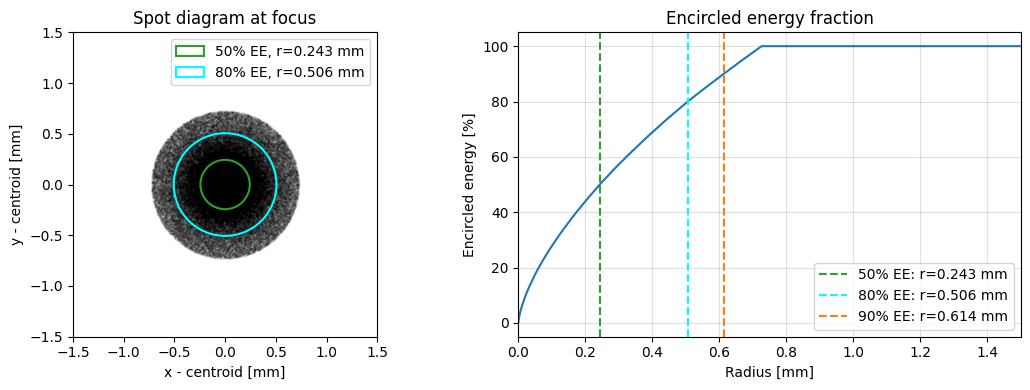

Flux-weighted centroid : (-0.0002, +0.0004) mm
50% encircled-energy radius: 0.2433 mm
80% encircled-energy radius: 0.5060 mm
90% encircled-energy radius: 0.6136 mm

This singlet is f/2.45 with no aberration correction, so the spot is spherical-aberration limited: a bright core inside a broad flare.


In [4]:
scene_rdb = NSQScene()
scene_rdb.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=10.0),
)
scene_rdb.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene_rdb.add_detector(
    'RDB', CoordinateSystem(z=FOCUS_Z),
    RayDatabaseConfig(width=6, height=6),
)

result_rdb = scene_rdb.trace(num_rays=200_000, seed=42)
db = result_rdb.detectors['RDB']

# --- Encircled energy fraction ---
cx = np.average(db.x, weights=db.flux)  # flux-weighted centroid
cy = np.average(db.y, weights=db.flux)
r_from_centre = np.sqrt((db.x - cx)**2 + (db.y - cy)**2)

# Sorting once turns the EEF into a cumulative sum, instead of one pass over the
# whole database per radius.
order = np.argsort(r_from_centre)
r_sorted = r_from_centre[order]
eef_sorted = np.cumsum(db.flux[order]) / db.flux.sum()


def ee_radius(fraction):
    """Radius enclosing `fraction` of the detected flux, linearly interpolated."""
    if eef_sorted[-1] < fraction:
        return np.nan  # never reaches this fraction on this detector
    return float(np.interp(fraction, eef_sorted, r_sorted))


r50, r80, r90 = ee_radius(0.50), ee_radius(0.80), ee_radius(0.90)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(db.x - cx, db.y - cy, s=0.5, alpha=0.05, c='k')
for r, c, lab in [(r50, 'tab:green', '50%'), (r80, 'cyan', '80%')]:
    axes[0].add_patch(plt.Circle((0, 0), r, color=c, fill=False, lw=1.5,
                                 label=f'{lab} EE, r={r:.3f} mm'))
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-1.5, 1.5)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x - centroid [mm]'); axes[0].set_ylabel('y - centroid [mm]')
axes[0].set_title('Spot diagram at focus')
axes[0].legend(loc='upper right')

axes[1].plot(r_sorted, eef_sorted * 100)
for r, c, lab in [(r50, 'tab:green', '50%'), (r80, 'cyan', '80%'),
                  (r90, 'tab:orange', '90%')]:
    axes[1].axvline(r, color=c, linestyle='--', label=f'{lab} EE: r={r:.3f} mm')
axes[1].set_xlim(0, 1.5)
axes[1].set_xlabel('Radius [mm]')
axes[1].set_ylabel('Encircled energy [%]')
axes[1].set_title('Encircled energy fraction')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Flux-weighted centroid : ({cx:+.4f}, {cy:+.4f}) mm")
print(f"50% encircled-energy radius: {r50:.4f} mm")
print(f"80% encircled-energy radius: {r80:.4f} mm")
print(f"90% encircled-energy radius: {r90:.4f} mm")
print("\nThis singlet is f/2.45 with no aberration correction, so the spot is "
      "spherical-aberration limited: a bright core inside a broad flare.")


## 4. Scene Validation

`scene.validate()` checks for the most common configuration mistakes. It is
called automatically by `scene.trace()`, but you can call it explicitly after
building the scene to catch errors early.

In [5]:
# A valid scene
scene_ok = NSQScene()
scene_ok.add_source('S', CoordinateSystem(z=0),
                    PointSourceConfig(spec, total_flux=1.0))
scene_ok.add_detector('D', CoordinateSystem(z=50),
                      IrradianceDetectorConfig(width=30, height=30))
scene_ok.validate()
print("Valid scene: passed")

# A scene missing a detector
scene_bad = NSQScene()
scene_bad.add_source('S', CoordinateSystem(z=0),
                     PointSourceConfig(spec, total_flux=1.0))
try:
    scene_bad.validate()
except ValueError as e:
    print(f"Validation error (expected): {e}")

Valid scene: passed
Validation error (expected): Scene has no detectors. Add at least one detector.


## 5. Performance Tips

### Choosing ray count

Monte Carlo noise scales as $1/\sqrt{N}$, so quadrupling the ray count halves
the noise. Start at 10k-50k rays while you get the geometry right, then raise it
for final results.

### Batch size matters more than you would expect

`batch_size` sets how many rays are traced at once. It does not change the
answer, but it does change the speed: the tracer allocates several temporary
arrays per ray per bounce, and once a batch no longer fits in cache the cost per
ray climbs sharply.

The default is 16,384 rays per batch, which sits in the middle of the measured
plateau on CPU. Very large batches are several times slower, so raise it only
when you have measured a gain on your own machine. The benchmark below is that
measurement.

Random numbers are drawn from a counter-based PCG32 keyed by
`(seed, ray_id, bounce, event_slot)` rather than a single shared stream, so a
ray's random decisions do not depend on which batch it was traced in or which
other rays were live alongside it. That is a stronger guarantee than "the
result converges" — for a fixed `seed`, the flux below should agree across
every `batch_size` to floating-point-summation precision, not just to Monte
Carlo tolerance. The benchmark below checks this directly.

### Component count

The tracer tests every surface against every live ray, so scenes with many
surfaces cost proportionally more. Drop components that no ray can reach, and use
absorbing surfaces to kill rays that cannot contribute.


In [6]:
import inspect
import time

# The default the tracer ships with, read straight off the signature.
DEFAULT_BATCH_SIZE = inspect.signature(NSQScene.trace).parameters['batch_size'].default


def build_bench_scene():
    s = NSQScene()
    s.add_source('S', CoordinateSystem(z=-80),
                 CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=10.0))
    s.add_lens('L', CoordinateSystem(z=0),
               LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                          front_aperture_radius=12.5))
    s.add_detector('D', CoordinateSystem(z=100),
                   IrradianceDetectorConfig(width=20, height=20,
                                            num_pixels_x=64, num_pixels_y=64))
    return s


build_bench_scene().trace(num_rays=5_000, seed=1)   # warm-up

N_BENCH = 400_000
batch_sizes = [2_000, 8_000, DEFAULT_BATCH_SIZE, 50_000, 200_000, 1_000_000]
times, rates, fluxes = [], [], []

for bs in batch_sizes:
    t0 = time.perf_counter()
    r = build_bench_scene().trace(num_rays=N_BENCH, seed=42, batch_size=bs)
    dt = time.perf_counter() - t0
    times.append(dt)
    rates.append(N_BENCH / dt / 1e6)
    fluxes.append(r.detectors['D'].total_flux)
    tag = '  <- default' if bs == DEFAULT_BATCH_SIZE else ''
    print(f"batch_size={bs:>9,}: {dt:6.3f} s  ->  {rates[-1]:.3f} M rays/s  "
          f"(flux {fluxes[-1]:.4f} W){tag}")

best = int(np.argmax(rates))
print(f"\nFastest: batch_size={batch_sizes[best]:,} at {rates[best]:.3f} M rays/s, "
      f"{rates[best] / rates[-1]:.1f}x the 1M-ray batch")
print(f"Flux spread across all batch sizes: {max(fluxes) - min(fluxes):.2e} W")
print("That is floating-point-summation noise (order of accumulation into the "
      "detector differs slightly by batch), not Monte Carlo noise: the same "
      "seed draws the same random decisions for every ray regardless of how "
      "batch_size splits the wavefront, so the run is reproducible, not just "
      "convergent.")


batch_size=    2,000:  4.017 s  ->  0.100 M rays/s  (flux 0.8637 W)


batch_size=    8,000:  2.313 s  ->  0.173 M rays/s  (flux 0.8637 W)


batch_size=   16,384:  1.992 s  ->  0.201 M rays/s  (flux 0.8637 W)  <- default


batch_size=   50,000:  2.387 s  ->  0.168 M rays/s  (flux 0.8637 W)


batch_size=  200,000:  5.890 s  ->  0.068 M rays/s  (flux 0.8637 W)


batch_size=1,000,000:  5.857 s  ->  0.068 M rays/s  (flux 0.8637 W)

Fastest: batch_size=16,384 at 0.201 M rays/s, 2.9x the 1M-ray batch
Flux spread across all batch sizes: 1.11e-16 W
That is floating-point-summation noise (order of accumulation into the detector differs slightly by batch), not Monte Carlo noise: the same seed draws the same random decisions for every ray regardless of how batch_size splits the wavefront, so the run is reproducible, not just convergent.


## 6. Inspecting Compound Component Internals

`scene.surfaces` is the flat list of every sub-surface the tracer actually sees.
Compound components name their parts, so a lens contributes `L1.front`,
`L1.back` and `L1.edge`, which makes it easy to find the surface you want to
modify or attach a BSDF to.


In [7]:
scene_inspect = NSQScene()
scene_inspect.add_source('S', CoordinateSystem(z=-80),
                         CollimatedSourceConfig(spec, total_flux=1.0,
                                                aperture_radius=10.0))
scene_inspect.add_lens('L1', CoordinateSystem(z=0),
                       LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                                  front_aperture_radius=12.5))
scene_inspect.add_lens('L2', CoordinateSystem(z=40),
                       LensConfig(r1=-80, r2=80, thickness=4, material='N-SF5',
                                  front_aperture_radius=12.5))
scene_inspect.add_detector('D', CoordinateSystem(z=120),
                           IrradianceDetectorConfig(width=10, height=10))

print("Compound components:")
for comp in scene_inspect.component_registry.compounds:
    print(f"  {comp.name}: {len(comp.surfaces)} surfaces")
    for surf in comp.surfaces:
        print(f"    - {surf.name:12s} {type(surf).__name__}")

print(f"\nFlat surface list  : {[s.name for s in scene_inspect.surfaces]}")
print(f"Total sources      : {len(scene_inspect.sources)}")
print(f"Total detectors    : {len(scene_inspect.detectors)}")

# Named surfaces make targeted modification straightforward.
front_of_L2 = next(s for s in scene_inspect.surfaces if s.name == 'L2.front')
print(f"\nLooked up '{front_of_L2.name}': {type(front_of_L2).__name__} "
      f"with aperture radius {front_of_L2.geometry.aperture_radius:.1f} mm")


Compound components:
  L1: 3 surfaces
    - L1.front     RefractiveComponent
    - L1.back      RefractiveComponent
    - L1.edge      AbsorbingComponent
  L2: 3 surfaces
    - L2.front     RefractiveComponent
    - L2.back      RefractiveComponent
    - L2.edge      AbsorbingComponent

Flat surface list  : ['L1.front', 'L1.back', 'L1.edge', 'L2.front', 'L2.back', 'L2.edge']
Total sources      : 1
Total detectors    : 1

Looked up 'L2.front': RefractiveComponent with aperture radius 12.5 mm


## 7. Putting It Together

The benchmark above and the scene it traced, side by side: throughput
against batch size, and the irradiance map the run produced.


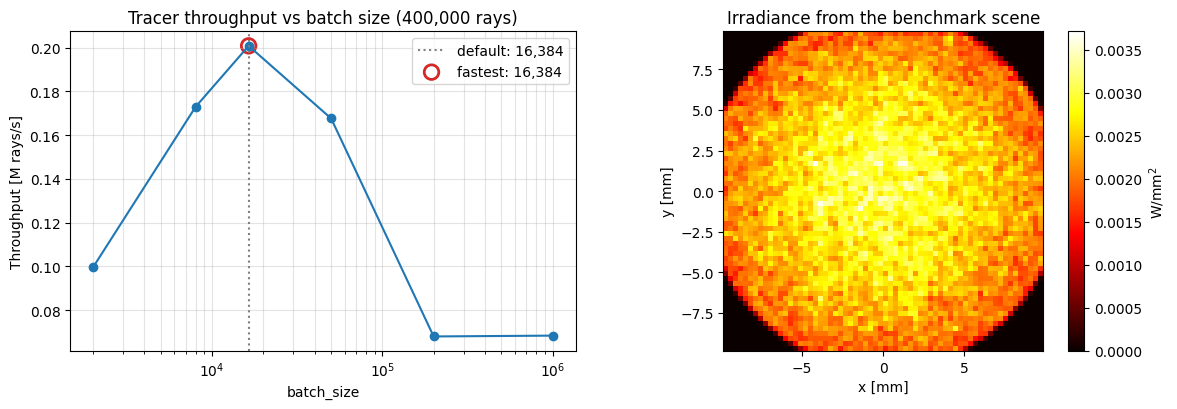

In [8]:
result_bench = build_bench_scene().trace(
    num_rays=200_000, seed=42, batch_size=batch_sizes[best])
irr_bench = result_bench.detectors['D']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.semilogx(batch_sizes, rates, 'o-')
ax.axvline(DEFAULT_BATCH_SIZE, color='0.5', ls=':', lw=1.5,
           label=f'default: {DEFAULT_BATCH_SIZE:,}')
ax.scatter([batch_sizes[best]], [rates[best]], s=110, facecolors='none',
           edgecolors='tab:red', linewidths=2,
           label=f'fastest: {batch_sizes[best]:,}')
ax.set_xlabel('batch_size')
ax.set_ylabel('Throughput [M rays/s]')
ax.set_title(f'Tracer throughput vs batch size ({N_BENCH:,} rays)')
ax.legend()
ax.grid(True, alpha=0.35, which='both')

ax = axes[1]
im = ax.imshow(irr_bench.irradiance, origin='lower', cmap='hot',
               extent=[irr_bench.x_coords[0], irr_bench.x_coords[-1],
                       irr_bench.y_coords[0], irr_bench.y_coords[-1]])
plt.colorbar(im, ax=ax, label='W/mm$^2$')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('Irradiance from the benchmark scene')

plt.tight_layout()
plt.show()


## 8. Rare-Path Sampling: Importance Biasing for Ghosts

An uncoated refractive surface still obeys Fresnel: most rays refract through,
but a small fraction — about 4% at a typical air/N-BK7 interface near normal
incidence — reflect instead and head back the way they came. That reflection
is a genuine "ghost" ray, and with only a handful of percent of the wavefront
taking that branch, a fixed ray budget spends most of its rays on paths you
were not asking about.

`scene.sampling_policy` (a `SamplingPolicy`) does not change *what* the
tracer computes, only how it spends rays. Its `reflect_prob` field controls
the probability used to draw the reflect/refract branch at every refractive
surface: `"fresnel"` (the default) draws from the physical Fresnel
reflectance itself, while a fixed value — `0.25`, say — draws the branch more
often than physically likely and compensates with an attached weight (the
same detached-sample/attached-weight estimator that keeps the branch
differentiable; see the developer guide). The *expected* flux on the ghost
path is unchanged; only its variance drops, because more of the ray budget
now lands on the rare branch instead of the common one.

The cell below reuses `DEMO_LENS` from the top of the notebook. Its front
surface has no coating, so it reflects ~4% of the collimated beam straight
back toward the source. A `RayDatabaseDetector` placed between the source and
the lens, with `absorb=False`, records every ray that crosses that plane
without stopping it — so the forward-going beam passes through untouched on
its way to the lens, and the backward-going (`N < 0`) reflection is recorded
on its way out.


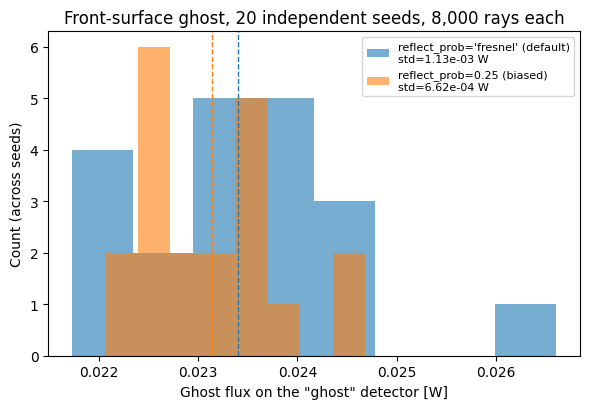

reflect_prob='fresnel': mean=0.02340 W, std=1.13e-03 W
reflect_prob=0.25     : mean=0.02314 W, std=6.62e-04 W
Same expectation to within Monte Carlo tolerance: 1.12% difference
Variance reduction: 2.9x, at zero extra rays and zero extra memory.


In [9]:
def ghost_flux(reflect_prob, num_rays=8_000, seed=0):
    """Flux reflected off the uncoated front face of DEMO_LENS, back toward the source."""
    scene = NSQScene()
    scene.add_source('S', CoordinateSystem(z=-80),
                     CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=10.0))
    scene.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
    scene.add_detector('ghost', CoordinateSystem(z=-40),
                       RayDatabaseConfig(width=25, height=25, absorb=False))
    scene.sampling_policy = SamplingPolicy(reflect_prob=reflect_prob)
    result = scene.trace(num_rays=num_rays, seed=seed)
    db = result.detectors['ghost']
    backward = db.N < 0   # the front-surface reflection, not the forward beam
    return float(db.flux[backward].sum())


# Repeat over several seeds so we can compare the *spread* of the ghost-flux
# estimate, not just a single value, between the default policy and a biased one.
seeds = range(20)
fresnel_vals = [ghost_flux('fresnel', seed=s) for s in seeds]
biased_vals = [ghost_flux(0.25, seed=s) for s in seeds]

fresnel_mean, fresnel_std = np.mean(fresnel_vals), np.std(fresnel_vals)
biased_mean, biased_std = np.mean(biased_vals), np.std(biased_vals)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.hist(fresnel_vals, bins=8, alpha=0.6, label=f"reflect_prob='fresnel' (default)\nstd={fresnel_std:.2e} W")
ax.hist(biased_vals, bins=8, alpha=0.6, label=f"reflect_prob=0.25 (biased)\nstd={biased_std:.2e} W")
ax.axvline(fresnel_mean, color='tab:blue', ls='--', lw=1)
ax.axvline(biased_mean, color='tab:orange', ls='--', lw=1)
ax.set_xlabel('Ghost flux on the "ghost" detector [W]')
ax.set_ylabel('Count (across seeds)')
ax.set_title(f'Front-surface ghost, {len(seeds)} independent seeds, {8_000:,} rays each')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"reflect_prob='fresnel': mean={fresnel_mean:.5f} W, std={fresnel_std:.2e} W")
print(f"reflect_prob=0.25     : mean={biased_mean:.5f} W, std={biased_std:.2e} W")
print(f"Same expectation to within Monte Carlo tolerance: "
      f"{abs(fresnel_mean - biased_mean) / fresnel_mean * 100:.2f}% difference")
print(f"Variance reduction: {(fresnel_std / biased_std) ** 2:.1f}x, "
      f"at zero extra rays and zero extra memory.")


## Summary

- `CoordinateSystem(x, y, z, rx, ry, rz)` - position [mm] and orientation [radians]
- Raw components (`RefractiveComponent`, `ReflectiveComponent`, `AbsorbingComponent`)
  plus a geometry are registered with `scene.add_component(name, component)` for
  shapes the compound builders (`Lens`, `Mirror`, `Doublet`) don't cover
- `RayDatabase` supports encircled energy, centroid, spot diagrams and custom analysis
- `scene.validate()` catches missing sources or detectors early
- Compound sub-surfaces are named (`L1.front`, `L1.back`, `L1.edge`), so they can be
  looked up in `scene.surfaces` and modified individually
- Noise falls as $1/\sqrt{N}$; quadruple the rays to halve it
- `batch_size` does not change the answer but strongly affects speed: the default
  of 16,384 is a good starting point, and very large batches are much slower.
  Results are reproducible (not just convergent) across `batch_size`, because the
  PCG32 RNG keys every random decision by `(seed, ray_id, bounce, event_slot)`
- `scene.sampling_policy.reflect_prob` biases rare paths (ghosts) toward more of
  the ray budget without changing the expected result -- pure variance reduction
- Check `flux_conservation_error` before interpreting any result
